# SnakeGuard AI: Snake Detection with YOLO

Dataset: [SnakeAid](https://universe.roboflow.com/snakeaid-ai/snakeaid)

## 1. Environment & Dataset Setup

In [1]:
!pip install -q -U ultralytics 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.8 MB/s eta 0:00:00


In [2]:
# Standard library
import random
import shutil
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

# Third-party libraries
import torch
import ultralytics
from matplotlib import patches
from PIL import Image

# Ultralytics
from ultralytics import YOLO

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics: 8.4.126
PyTorch: 2.10.0+cu128
GPU: Tesla T4


In [3]:
# Config data path
DATASET_DIR = Path("/kaggle/input/datasets/lthhnglam/snakeaid-v8/SnakeAid-v8")
TRAIN_DIR = DATASET_DIR / "train"
VALID_DIR = DATASET_DIR / "valid"
TEST_DIR = DATASET_DIR / "test"
DATA_YAML = DATASET_DIR / "data.yaml"

## 2. Preprocessing Data

### 2.1. Data Exploration

In [4]:
# Statistics dataset

class_counts = Counter()

for split in ["train", "valid", "test"]:
    image_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"

    num_images = len(list(image_dir.glob("*.jpg")))
    num_labels = len(list(label_dir.glob("*.txt")))

    print(f"{split:<5} | images: {num_images:<5} | labels: {num_labels:<5}")

    if split == "train":
        for label_file in label_dir.glob("*.txt"):
            for line in label_file.read_text().splitlines():
                if line.strip():
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

print("\nNumber of classes:", len(class_counts))
print("Class IDs:", sorted(class_counts.keys()))
print("\nBounding boxes per class:")

for class_id, count in sorted(class_counts.items()):
    print(f"Class {class_id:2}: {count}")

train | images: 4795  | labels: 4795 
valid | images: 265   | labels: 265  
test  | images: 231   | labels: 231  

Number of classes: 22
Class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

Bounding boxes per class:
Class  0: 252
Class  1: 246
Class  2: 219
Class  3: 225
Class  4: 156
Class  5: 261
Class  6: 235
Class  7: 242
Class  8: 231
Class  9: 233
Class 10: 229
Class 11: 240
Class 12: 87
Class 13: 233
Class 14: 202
Class 15: 217
Class 16: 229
Class 17: 255
Class 18: 181
Class 19: 209
Class 20: 222
Class 21: 195


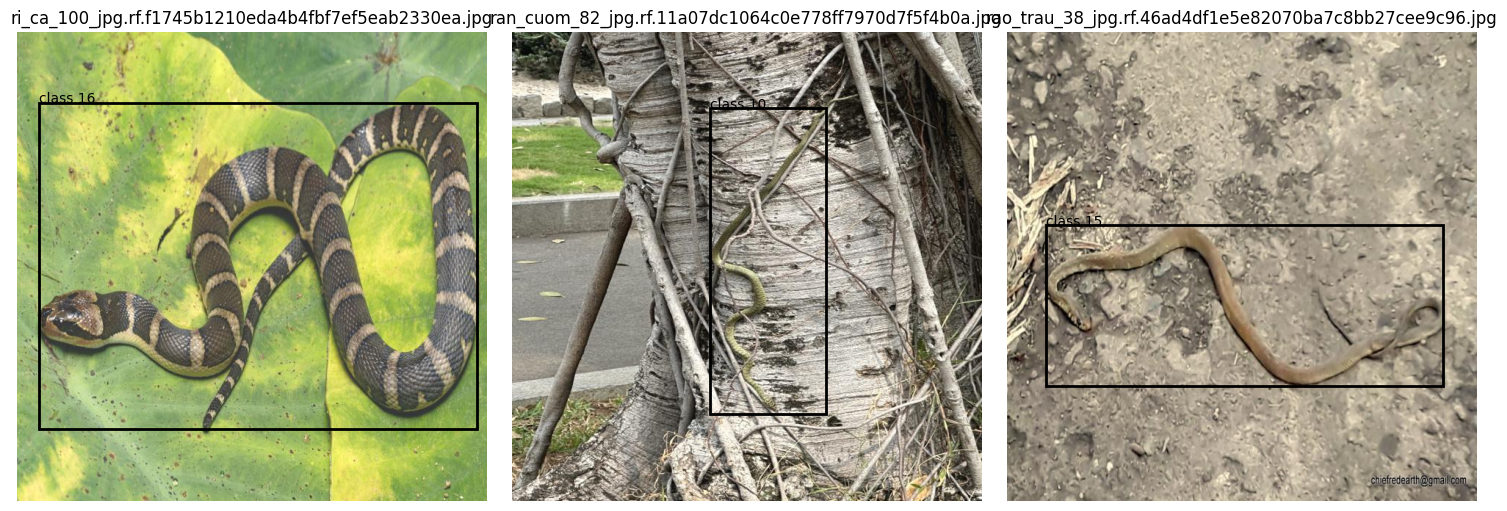

In [5]:
# Visual some image with bbox
image_dir = TRAIN_DIR / "images"
label_dir = TRAIN_DIR / "labels"

sample_images = random.sample(list(image_dir.glob("*.jpg")), 3)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, image_path in zip(axes, sample_images):
    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    ax.imshow(image)
    label_path = label_dir / f"{image_path.stem}.txt"

    for line in label_path.read_text().splitlines():
        class_id, xc, yc, bw, bh = map(float, line.split())

        x = (xc - bw / 2) * width
        y = (yc - bh / 2) * height

        rect = patches.Rectangle((x, y), bw * width, bh * height, linewidth=2, fill=False,)
        ax.add_patch(rect)
        ax.text(x, y, f"class {int(class_id)}")

    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 2.2. Prepare dataset for trainning

SnakeGuard uses YOLO only to locate snakes, not to classify species.

Therefore, all 22 original SnakeAid classes are collapsed into a single class: `0: snake`

Bounding-box coordinates remain unchanged.

In [6]:
# Copy dataset and convert bbox
PROCESSED_DIR = Path("/kaggle/working/snakeaid_1class")
num_boxes = 0

for split in ["train", "valid", "test"]:
    src_dir = DATASET_DIR / split
    dst_dir = PROCESSED_DIR / split

    shutil.copytree(src_dir, dst_dir)

    for label_path in (dst_dir / "labels").glob("*.txt"):
        new_lines = []

        for line in label_path.read_text().splitlines():
            if line.strip():
                parts = line.split()
                parts[0] = "0"

                new_lines.append(" ".join(parts))
                num_boxes += 1

        label_path.write_text("\n".join(new_lines))

print("Converted bounding boxes:", num_boxes)

Converted bounding boxes: 5295


In [7]:
# create new YAML
PROCESSED_YAML = Path("/kaggle/working/snakeaid_1class.yaml")

PROCESSED_YAML.write_text(
f"""path: {PROCESSED_DIR}

train: train/images
val: valid/images
test: test/images

names:
  0: snake
"""
)

114

In [8]:
# Checking after convert

class_ids = set()
invalid_labels = []

for split in ["train", "valid", "test"]:
    for label_path in (PROCESSED_DIR / split / "labels").glob("*.txt"):
        for line_num, line in enumerate(label_path.read_text().splitlines(), 1):
            if not line.strip():
                continue

            parts = line.split()

            if len(parts) != 5:
                invalid_labels.append((label_path, line_num, "wrong format"))
                continue

            class_id, xc, yc, w, h = map(float, parts)
            class_ids.add(int(class_id))

            if class_id != 0:
                invalid_labels.append((label_path, line_num, "invalid class"))

            if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
                invalid_labels.append((label_path, line_num, "invalid bbox"))

print("Class IDs after conversion:", class_ids)
print("Invalid labels:", len(invalid_labels))

Class IDs after conversion: {0}
Invalid labels: 0


## 3. YOLO26 Training

In [9]:
RUNS_DIR = Path("/kaggle/working/runs")

model_26n = YOLO("yolo26n.pt")
results_26n = model_26n.train(
    data=str(PROCESSED_YAML), epochs=100, imgsz=640, batch=16,
    project=str(RUNS_DIR), name="yolo26n_snake", patience=15, seed=42
)

Ultralytics 8.4.126 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/snakeaid_1class.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_snake, nbs=64, n

## 4. Evaluation YOLO26

In [11]:
BEST_26N = RUNS_DIR / "yolo26n_snake" / "weights" / "best.pt"

best_26n = YOLO(str(BEST_26N))
metrics_26n = best_26n.val(data=str(PROCESSED_YAML), split="test", imgsz=640, batch=16)

print(f"Precision:   {metrics_26n.box.mp:.4f}")
print(f"Recall:      {metrics_26n.box.mr:.4f}")
print(f"mAP50:       {metrics_26n.box.map50:.4f}")
print(f"mAP50-95:    {metrics_26n.box.map:.4f}")
print(f"Inference:   {metrics_26n.speed['inference']:.2f} ms/image")

Ultralytics 8.4.126 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1467.6±473.6 MB/s, size: 69.6 KB)
val: Scanning /kaggle/working/snakeaid_1class/test/labels... 231 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 231/231 1.4Kit/s 0.2s
val: New cache created: /kaggle/working/snakeaid_1class/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 5.6it/s 2.7s
                   all        231        231      0.968      0.931      0.968      0.824
Speed: 2.0ms preprocess, 4.5ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
Precision:   0.9678
Recall:      0.9307
mAP50:       0.9683
mAP50-95:    0.8243
Inference:   4.50 ms/image
